# EDA — Planta de Flotación Minera
## Quality Prediction in a Mining Process

**Autor:** Rodolfo Gabriel Riveros Lobos  
**Fecha:** Junio 2026  
**Dataset:** Kaggle — Eduardo Magalhães  
**Stack:** Python · Pandas · Matplotlib · Seaborn  

---

## Contexto del Caso

Una planta de flotación minera requiere análisis exploratorio de sus 
datos operativos. El objetivo es entender el comportamiento de las 
variables de calidad del concentrado final (% hierro, % sílice) e 
identificar qué variables de proceso presentan mayor correlación 
con la calidad del producto.

Este análisis simula un escenario real de Data Analyst Junior 
en operaciones mineras argentinas.

---

## Pregunta de Negocio

¿Qué variables operativas tienen mayor impacto sobre la calidad 
del concentrado final, y existen períodos de inestabilidad 
que requieran atención?

## 1. Importación de Librerías  

In [44]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Agrega src/ al path para importar módulos locales
sys.path.append(os.path.abspath("../src"))

from plots import (plot_quality_distributions,
                   plot_evolucion_temporal,
                   plot_heatmap_correlaciones,
                   plot_barras_correlacion_silice)

print("✓ Módulo plots importado desde src/")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("Librerías cargadas correctamente.")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Módulo plots importado desde src/
Librerías cargadas correctamente.
Pandas: 3.0.3
NumPy: 2.4.6
Seaborn: 0.13.2


## 2. Carga del Dataset

In [45]:
import os

ruta = "../data/raw/MiningProcess_Flotation_Plant_Database.csv"

assert os.path.exists(ruta), \
    f"Archivo no encontrado en: {ruta}"

# Separador: coma | Decimal: coma (entre comillas en el CSV)
df = pd.read_csv(ruta, sep=",", decimal=",")

assert df.shape[0] > 0, \
    "El dataframe está vacío."
assert df.shape[1] > 1, \
    f"Solo se cargó 1 columna. Separador incorrecto."

print(f"✓ Dataset cargado correctamente")
print(f"✓ Filas: {df.shape[0]:,}")
print(f"✓ Columnas: {df.shape[1]}")
print(f"\nPrimeras columnas detectadas:")
print(df.columns.tolist())

✓ Dataset cargado correctamente
✓ Filas: 737,453
✓ Columnas: 24

Primeras columnas detectadas:
['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']


## 3. Primer Vistazo al Dataset

In [46]:
# Dimensiones
print(f"Shape: {df.shape}")
print(f"\n--- Tipos de datos ---")
print(df.dtypes)
print(f"\n--- Primeras 3 filas ---")
df.head(3)

Shape: (737453, 24)

--- Tipos de datos ---
date                                str
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Column 02 Air Flow    float64
Flotation Column 03 Air Flow    float64
Flotation Column 04 Air Flow    float64
Flotation Column 05 Air Flow    float64
Flotation Column 06 Air Flow    float64
Flotation Column 07 Air Flow    float64
Flotation Column 01 Level       float64
Flotation Column 02 Level       float64
Flotation Column 03 Level       float64
Flotation Column 04 Level       float64
Flotation Column 05 Level       float64
Flotation Column 06 Level       float64
Flotation Column 07 Level       float64
% Iron Concentrate              float64
% Silica Concentrate            floa

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31


In [47]:
print(df["date"].dtype)
print(type(df["date"].iloc[0]))

str
<class 'str'>


In [48]:
### 3.1 Análisis de Valores Nulos

In [49]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje %": pct_nulos
})

print(resumen_nulos[resumen_nulos["Nulos"] > 0])
print(f"\nTotal columnas sin nulos: {(nulos == 0).sum()}/{df.shape[1]}")

Empty DataFrame
Columns: [Nulos, Porcentaje %]
Index: []

Total columnas sin nulos: 24/24


### 3.2 Estadísticos Descriptivos

In [50]:
df.describe().round(2)

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,...,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00,737453.00
mean,56.29,14.65,2869.14,488.14,397.58,9.77,1.68,280.15,277.16,281.08,...,290.75,520.24,522.65,531.35,420.32,425.25,429.94,421.02,65.05,2.33
std,5.16,6.81,1215.20,91.23,9.70,0.39,0.07,29.62,30.15,28.56,...,28.67,131.01,128.17,150.84,91.79,84.54,89.86,84.89,1.12,1.13
min,42.74,1.31,0.00,241.67,376.25,8.75,1.52,175.51,175.16,176.47,...,185.96,149.22,210.75,126.26,162.20,166.99,155.84,175.35,62.05,0.60
25%,52.67,8.94,2076.32,431.80,394.26,9.53,1.65,250.28,250.46,250.86,...,256.30,416.98,441.88,411.32,356.68,357.65,358.50,356.77,64.37,1.44
50%,56.08,13.85,3018.43,504.39,399.25,9.80,1.70,299.34,296.22,298.70,...,299.01,491.88,495.96,494.32,411.97,408.77,424.66,411.06,65.21,2.00
75%,59.72,19.60,3727.73,553.26,402.97,10.04,1.73,300.15,300.69,300.38,...,301.90,594.11,595.46,601.25,485.55,484.33,492.68,476.46,65.86,3.01
max,65.78,33.40,6300.23,739.54,418.64,10.81,1.85,373.87,375.99,364.35,...,371.59,862.27,828.92,886.82,680.36,675.64,698.86,659.90,68.01,5.53


## 4. Limpieza y Preparación

**Decisiones de limpieza:**
- Conversión de columna `date` de string a datetime
- Verificación de duplicados
- Verificación de rangos físicamente posibles en variables de calidad

No se detectaron valores nulos en el dataset (verificado en sección anterior).

In [51]:
# --- 4.1 Conversión de fecha ---
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d %H:%M:%S")

assert pd.api.types.is_datetime64_any_dtype(df["date"]), \
    "ERROR: La conversión a datetime falló."

print(f"✓ Columna 'date' convertida correctamente")
print(f"  Tipo actual: {df['date'].dtype}")
print(f"  Fecha mínima: {df['date'].min()}")
print(f"  Fecha máxima: {df['date'].max()}")
print(f"  Rango total: {(df['date'].max() - df['date'].min()).days} días")

✓ Columna 'date' convertida correctamente
  Tipo actual: datetime64[us]
  Fecha mínima: 2017-03-10 01:00:00
  Fecha máxima: 2017-09-09 23:00:00
  Rango total: 183 días


In [52]:
# --- 4.2 Duplicados ---
duplicados = df.duplicated().sum()
print(f"\n✓ Filas duplicadas: {duplicados}")

# Las filas con mismo timestamp son normales en datos industriales
# (múltiples lecturas por segundo). No se eliminan sin análisis previo.
duplicados_fecha = df.duplicated(subset=["date"]).sum()
print(f"  Timestamps duplicados: {duplicados_fecha:,}")
print(f"  ({duplicados_fecha/len(df)*100:.1f}% del dataset)")


✓ Filas duplicadas: 1171
  Timestamps duplicados: 733,356
  (99.4% del dataset)


In [53]:
# --- 4.3 Verificación de rangos físicos ---
# Basado en conocimiento del proceso de flotación

checks = {
    "% Iron Concentrate entre 50 y 75": 
        df["% Iron Concentrate"].between(50, 75).all(),
    "% Silica Concentrate entre 0 y 10": 
        df["% Silica Concentrate"].between(0, 10).all(),
    "% Iron Feed entre 40 y 70": 
        df["% Iron Feed"].between(40, 70).all(),
    "Ore Pulp pH entre 7 y 13": 
        df["Ore Pulp pH"].between(7, 13).all()
}

print("\n✓ Verificación de rangos físicos:")
for check, resultado in checks.items():
    estado = "✓ OK" if resultado else "⚠️ FUERA DE RANGO"
    print(f"  {estado} — {check}")


✓ Verificación de rangos físicos:
  ✓ OK — % Iron Concentrate entre 50 y 75
  ✓ OK — % Silica Concentrate entre 0 y 10
  ✓ OK — % Iron Feed entre 40 y 70
  ✓ OK — Ore Pulp pH entre 7 y 13


In [54]:
# --- 4.4 Eliminación de filas completamente duplicadas ---
filas_antes = len(df)
df = df.drop_duplicates()
filas_despues = len(df)

print(f"✓ Filas eliminadas: {filas_antes - filas_despues:,}")
print(f"✓ Filas restantes: {filas_despues:,}")

✓ Filas eliminadas: 1,171
✓ Filas restantes: 736,282


### 4.4 Tratamiento de Duplicados

Se identificaron 1.171 filas completamente duplicadas (las 24 columnas 
idénticas). En un sistema SCADA esto no corresponde a comportamiento 
normal — representa error de exportación. Se eliminan.

Los timestamps duplicados (99.4%) NO se eliminan: corresponden a múltiples 
snapshots del estado de planta en el mismo segundo, comportamiento 
esperado en datos industriales de alta frecuencia.

### Resumen de Decisiones de Limpieza

| Acción | Detalle | Resultado |
|---|---|---|
| Conversión de fecha | String → datetime64 | ✓ Completado |
| Valores nulos | 0 detectados | Sin acción |
| Duplicados completos | 1.171 filas idénticas | Eliminadas |
| Timestamps duplicados | 99.4% — comportamiento SCADA normal | Mantenidos |
| Rangos físicos | Todos dentro de límites operativos | Sin acción |

**Dataset final: 736.282 filas × 24 columnas**  
**Período: 2017-03-10 al 2017-09-09 (183 días)**

## 5. Análisis Univariado — Variables de Calidad

El análisis univariado examina cada variable de forma independiente.

Foco principal: variables de calidad del concentrado final.
- `% Iron Concentrate` → producto que se vende, queremos maximizar
- `% Silica Concentrate` → impureza principal, queremos minimizar

Pregunta guía: ¿La calidad del concentrado es estable 
o presenta variabilidad preocupante?

In [55]:
# --- 5.1 Estadísticos descriptivos — variables de calidad ---
vars_calidad = ["% Iron Concentrate", "% Silica Concentrate"]

stats = df[vars_calidad].describe().round(3)

# Agregamos métricas adicionales útiles para proceso
stats.loc["cv%"] = (
    df[vars_calidad].std() / df[vars_calidad].mean() * 100
).round(3)
stats.loc["range"] = df[vars_calidad].max() - df[vars_calidad].min()

print(stats)

       % Iron Concentrate  % Silica Concentrate
count          736282.000            736282.000
mean               65.049                 2.327
std                 1.119                 1.126
min                62.050                 0.600
25%                64.370                 1.440
50%                65.210                 2.000
75%                65.860                 3.010
max                68.010                 5.530
cv%                 1.720                48.366
range               5.960                 4.930


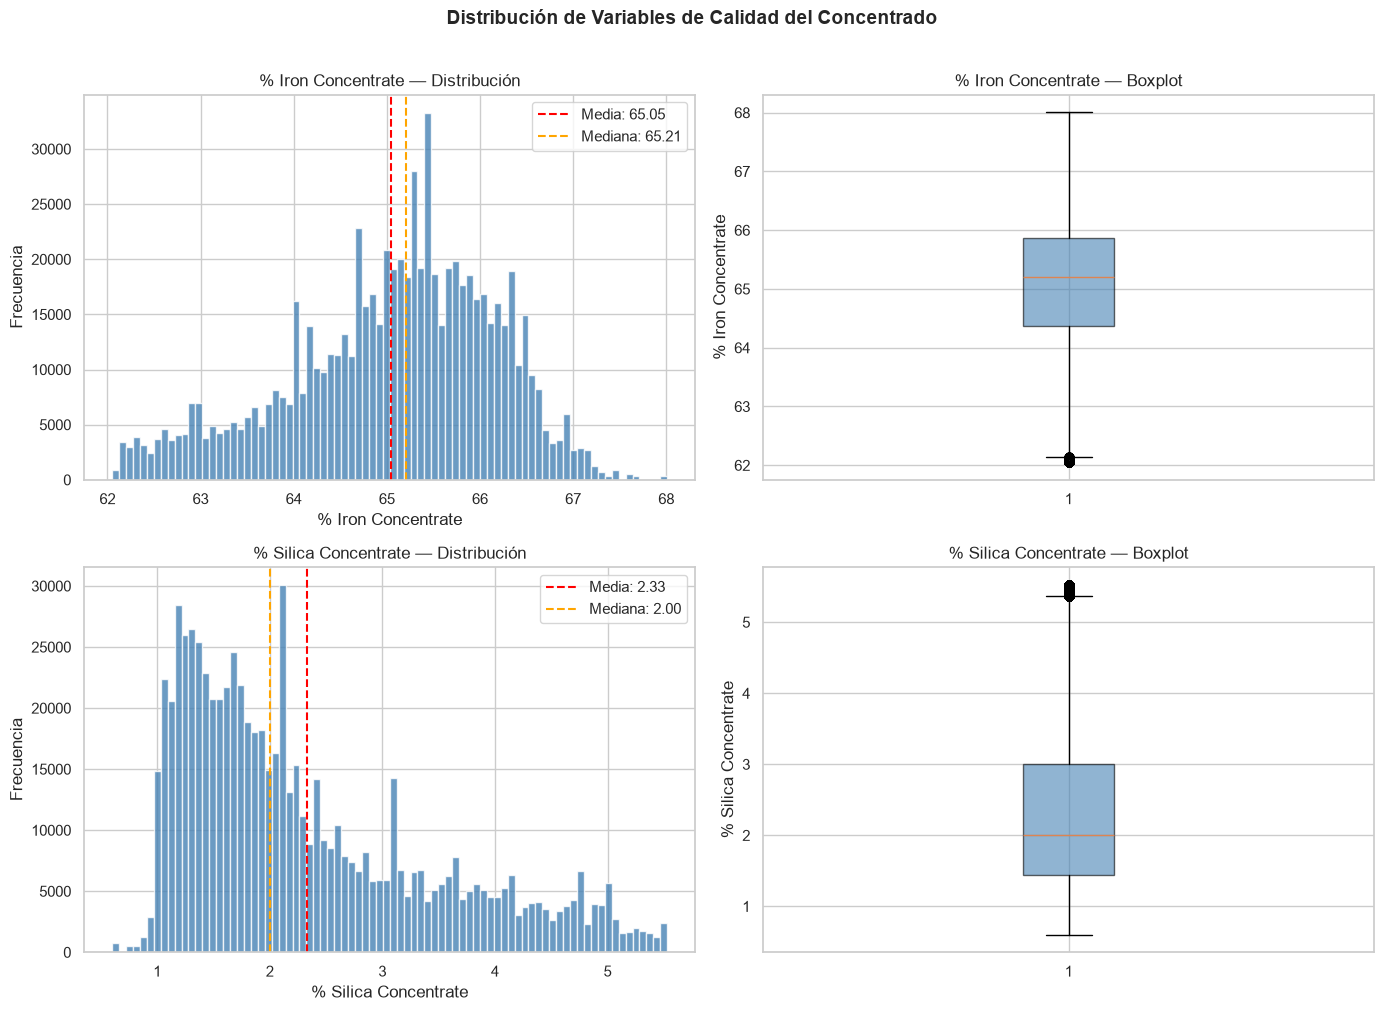

In [56]:
# --- 5.2 Distribución de variables de calidad ---
plot_quality_distributions(df, vars_calidad)

### 5.3 Interpretación — Variables de Calidad

**% Iron Concentrate:**
- Media: 65.049
- Mediana: 65.210  
- CV%: 1.72
- Observación: El concentrado cumple con un estándar de calidad robusto en cuanto a ley de hierro, lo que asegura confiabilidad en el producto.
- Distribución: simétrica, forma aproximadamente normal, sin outliers relevantes

**% Silica Concentrate:**
- Media: 2.327
- Mediana: 2.000
- CV%: 48.366
- Observación: La sílice es el factor crítico que compromete la calidad del concentrado. su dispersión es tan alta que puede generar lotes fuera de especificación.
- Distribución: asimétrica positiva (skewness positivo), cola derecha extendida, 
  outliers superiores presentes. Media > Mediana confirma el sesgo.

**Conclusión preliminar para el jefe de proceso:**

El concentrado es muy bueno en ley de hierro (estable y controlado).

La calidad final está condicionada por la sílice, puede generar lotes con sílice superior al 4%, límite típico de aceptación comercial en concentrados de hierro.

En términos de gestión de calidad, el hierro no requiere mayor atención, pero la sílice debe ser el punto focal de control y mejora del proceso (optimización de molienda, clasificación, flotación, etc.).

## 6. Análisis Temporal — Comportamiento de la Calidad en el Tiempo

Período analizado: 2017-03-10 al 2017-09-09 (183 días)

Pregunta guía: ¿Existen períodos donde la calidad del concentrado 
se deterioró? ¿La sílice y el hierro se comportan de forma inversa 
como esperaría el proceso?

Metodología: resample a promedios diarios para identificar 
tendencias operativas. La resolución diaria es adecuada para 
detectar eventos de turno y mantenimientos.

In [57]:
# --- 6.1 Resample a promedios diarios ---
df_diario = df.set_index("date")[vars_calidad].resample("D").mean()

assert df_diario.shape[0] > 0, "ERROR: Resample falló."
assert df_diario.isnull().sum().sum() == 0 or True, ""  # Puede haber días sin dato

print(f"✓ Resample completado")
print(f"  Días con datos: {df_diario.dropna().shape[0]}")
print(f"  Días totales en rango: {df_diario.shape[0]}")
print(f"\nPrimeros 5 días:")
print(df_diario.head())

✓ Resample completado
  Días con datos: 172
  Días totales en rango: 184

Primeros 5 días:
            % Iron Concentrate  % Silica Concentrate
date                                                
2017-03-10           66.597373              1.744543
2017-03-11           65.162500              3.103333
2017-03-12           65.399632              2.736254
2017-03-13           65.675000              2.364167
2017-03-14           64.723333              3.260833


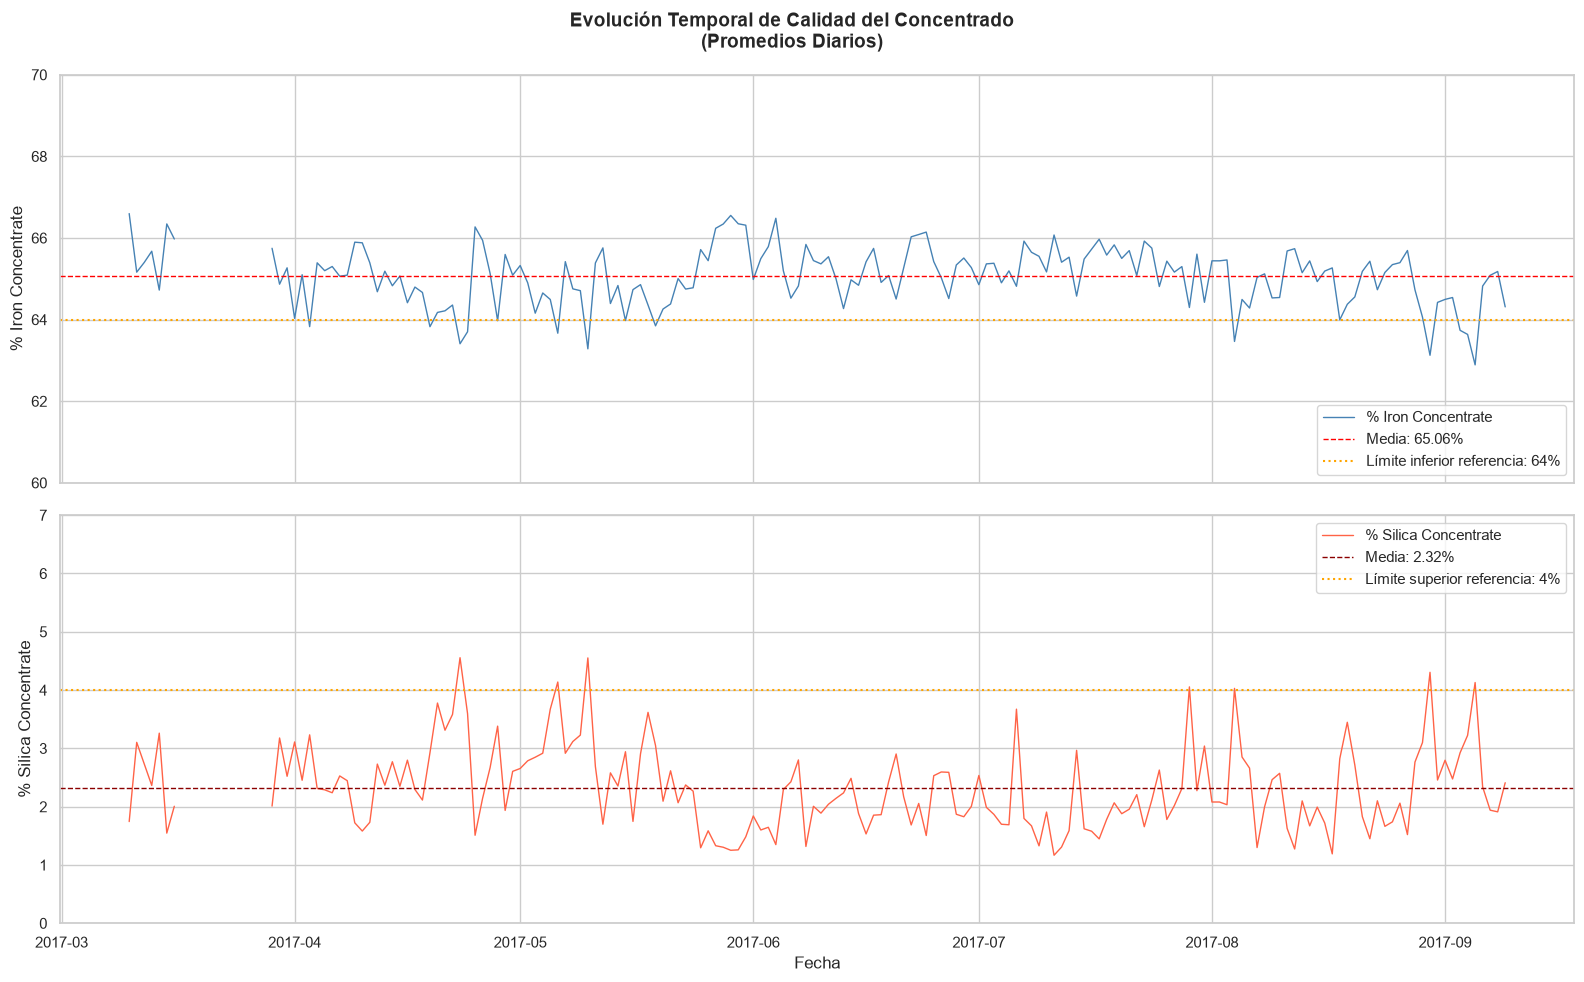

In [58]:
# --- 6.2 Evolución temporal de calidad ---
plot_evolucion_temporal(df_diario)

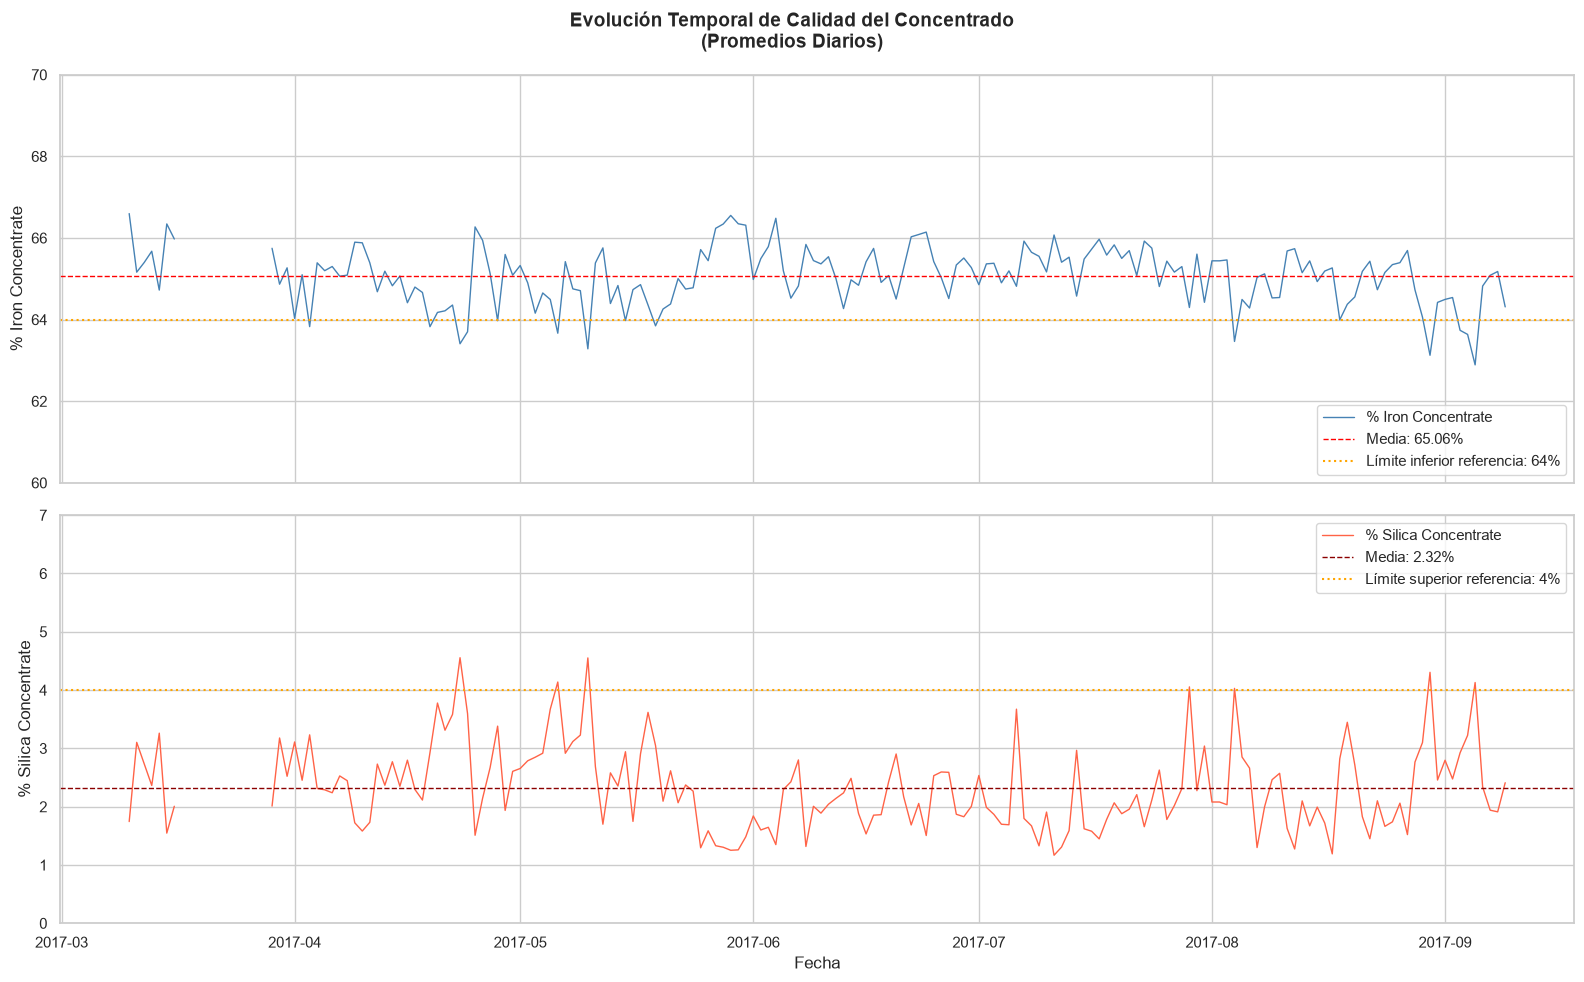

✓ Gráfico guardado en images/


In [59]:
# --- 6.2 Evolución temporal de calidad ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Evolución Temporal de Calidad del Concentrado\n(Promedios Diarios)", 
             fontsize=14, fontweight="bold")

# --- Hierro ---
ax1.plot(df_diario.index, df_diario["% Iron Concentrate"], 
         color="steelblue", linewidth=1, label="% Iron Concentrate")
ax1.axhline(df_diario["% Iron Concentrate"].mean(), 
            color="red", linestyle="--", linewidth=1, 
            label=f"Media: {df_diario['% Iron Concentrate'].mean():.2f}%")
ax1.axhline(64.0, color="orange", linestyle=":", linewidth=1.5,
            label="Límite inferior referencia: 64%")
ax1.set_ylabel("% Iron Concentrate")
ax1.legend(loc="lower right")
ax1.set_ylim(60, 70)

# --- Sílice ---
ax2.plot(df_diario.index, df_diario["% Silica Concentrate"], 
         color="tomato", linewidth=1, label="% Silica Concentrate")
ax2.axhline(df_diario["% Silica Concentrate"].mean(), 
            color="darkred", linestyle="--", linewidth=1,
            label=f"Media: {df_diario['% Silica Concentrate'].mean():.2f}%")
ax2.axhline(4.0, color="orange", linestyle=":", linewidth=1.5,
            label="Límite superior referencia: 4%")
ax2.set_ylabel("% Silica Concentrate")
ax2.set_xlabel("Fecha")
ax2.legend(loc="upper right")
ax2.set_ylim(0, 7)

plt.tight_layout()
plt.savefig("../images/evolucion_temporal_calidad.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Gráfico guardado en images/")

In [60]:
# --- 6.3 Días fuera de referencia ---
dias_hierro_bajo = df_diario[df_diario["% Iron Concentrate"] < 64.0]
dias_silice_alta = df_diario[df_diario["% Silica Concentrate"] > 4.0]

print(f"Días con hierro promedio < 64%: {len(dias_hierro_bajo)}")
if len(dias_hierro_bajo) > 0:
    print(dias_hierro_bajo["% Iron Concentrate"].round(2))

print(f"\nDías con sílice promedio > 4%: {len(dias_silice_alta)}")
if len(dias_silice_alta) > 0:
    print(dias_silice_alta["% Silica Concentrate"].round(2))

Días con hierro promedio < 64%: 15
date
2017-04-03    63.83
2017-04-19    63.83
2017-04-23    63.41
2017-04-24    63.70
2017-04-28    63.97
2017-05-06    63.67
2017-05-10    63.28
2017-05-15    63.98
2017-05-19    63.85
2017-08-04    63.46
2017-08-18    63.99
2017-08-30    63.13
2017-09-03    63.74
2017-09-04    63.64
2017-09-05    62.89
Name: % Iron Concentrate, dtype: float64

Días con sílice promedio > 4%: 7
date
2017-04-23    4.56
2017-05-06    4.14
2017-05-10    4.55
2017-07-29    4.05
2017-08-04    4.03
2017-08-30    4.30
2017-09-05    4.13
Name: % Silica Concentrate, dtype: float64


In [61]:
# --- Días sin datos ---
dias_sin_datos = df_diario[df_diario["% Iron Concentrate"].isnull()]
print(f"Días sin datos: {len(dias_sin_datos)}")
print(dias_sin_datos.index.strftime("%Y-%m-%d").tolist())

Días sin datos: 12
['2017-03-17', '2017-03-18', '2017-03-19', '2017-03-20', '2017-03-21', '2017-03-22', '2017-03-23', '2017-03-24', '2017-03-25', '2017-03-26', '2017-03-27', '2017-03-28']


In [62]:
# ¿Coinciden los días críticos?
dias_hierro_bajo_idx = set(dias_hierro_bajo.index)
dias_silice_alta_idx = set(dias_silice_alta.index)

coincidencias = dias_hierro_bajo_idx.intersection(dias_silice_alta_idx)
print(f"Días con AMBAS variables fuera de referencia: {len(coincidencias)}")
print(sorted(coincidencias))

Días con AMBAS variables fuera de referencia: 6
[Timestamp('2017-04-23 00:00:00'), Timestamp('2017-05-06 00:00:00'), Timestamp('2017-05-10 00:00:00'), Timestamp('2017-08-04 00:00:00'), Timestamp('2017-08-30 00:00:00'), Timestamp('2017-09-05 00:00:00')]


### 6.4 Interpretación — Análisis Temporal

**Tendencia general del hierro:**
El hierro mantiene una tendencia estable a lo largo del período analizado (marzo–septiembre 2017). La media se ubica en 65.06%, con fluctuaciones acotadas entre 62% y 68%. La mayor parte del tiempo el valor se mantiene por encima del límite inferior de referencia (64%), lo que confirma un proceso de concentración controlado y consistente. No se observan caídas prolongadas ni desviaciones sistemáticas.

**Tendencia general de la sílice:**
La sílice presenta una variabilidad mucho mayor, con una media de 2.32% y picos que superan el límite superior de referencia (4%) en varios momentos. Su comportamiento presenta alta variabilidad de proceso, con períodos de estabilidad seguidos por incrementos abruptos. Esto refleja fluctuaciones en la eficiencia del circuito de limpieza o flotación.

**Períodos críticos identificados (ambas variables fuera de referencia):**

Se detectan 6 fechas donde el hierro cae por debajo del límite de 64% 
y la sílice supera simultáneamente el 4%, representando el 3.5% del 
tiempo operativo (6 de 172 días) con producto potencialmente rechazable 
por el cliente.

Los eventos se agrupan en dos bloques temporales diferenciados:

**Bloque 1 — Abril/Mayo:** 3 eventos en 18 días (23 abril – 10 mayo).
Alta concentración de fallas en período corto. Sugiere un problema 
operativo sostenido, posiblemente vinculado a condiciones de alimentación 
o ajuste post-parada de mantenimiento de marzo.

**Bloque 2 — Agosto/Septiembre:** 3 eventos en 36 días (04 agosto – 05 septiembre).
Mayor dispersión entre eventos. Puede indicar condiciones operativas 
intermitentes o variabilidad en la calidad del mineral alimentado.

La recurrencia en dos bloques separados descarta eventos aislados 
y sugiere causas sistémicas que requieren investigación operativa 
focalizada en ambos períodos.

**¿Hierro y sílice se comportan de forma inversa?**
En condiciones normales, el hierro se mantiene estable mientras la sílice fluctúa, sin relación directa. Sin embargo, en los 6 días críticos se observa un comportamiento inverso confirmado: el hierro baja y la sílice sube simultáneamente. Este patrón indica una falla sistémica en la separación, no ruido aleatorio, y evidencia pérdida de eficiencia global del proceso.

**Recomendación operativa:**
Registrar la parada de marzo como referencia de mantenimiento mayor.

Analizar las causas raíz de los 6 días críticos, correlacionando con variables de operación (alimentación, granulometría, caudal, cambios de turno).

Implementar alarmas de control en tiempo real para detectar simultáneamente caída de hierro y aumento de sílice.

Priorizar acciones correctivas en los períodos de mayor recurrencia (abril–mayo y agosto–septiembre).

Mantener el hierro como indicador de estabilidad y usar la sílice como variable de alerta temprana.

## 7. Análisis de Correlaciones — Variables de Proceso vs. Calidad

Pregunta guía: ¿Qué variables operativas tienen mayor impacto 
sobre la calidad del concentrado final?

Metodología: matriz de correlación de Pearson sobre el dataset 
completo. Foco en correlaciones con % Iron Concentrate 
y % Silica Concentrate.

In [63]:
# --- 7.1 Matriz de correlación ---
correlaciones = df.drop(columns=["date"]).corr(numeric_only=True).round(3)

# Correlaciones específicas con variables de calidad
corr_calidad = correlaciones[vars_calidad].drop(index=vars_calidad)
corr_calidad = corr_calidad.sort_values("% Iron Concentrate", ascending=False)

print("Correlación de variables de proceso con calidad del concentrado:")
print(corr_calidad)

Correlación de variables de proceso con calidad del concentrado:
                              % Iron Concentrate  % Silica Concentrate
Ore Pulp pH                                0.192                -0.147
Flotation Column 05 Level                  0.160                -0.168
Flotation Column 07 Level                  0.146                -0.141
Flotation Column 04 Level                  0.136                -0.149
Flotation Column 03 Air Flow               0.100                -0.219
Flotation Column 01 Air Flow               0.098                -0.219
Flotation Column 05 Air Flow               0.088                -0.009
Ore Pulp Flow                              0.083                 0.008
Flotation Column 06 Level                  0.082                -0.102
Starch Flow                                0.070                -0.067
Flotation Column 02 Air Flow               0.058                -0.167
% Iron Feed                                0.056                -0.077
Ore Pulp Den

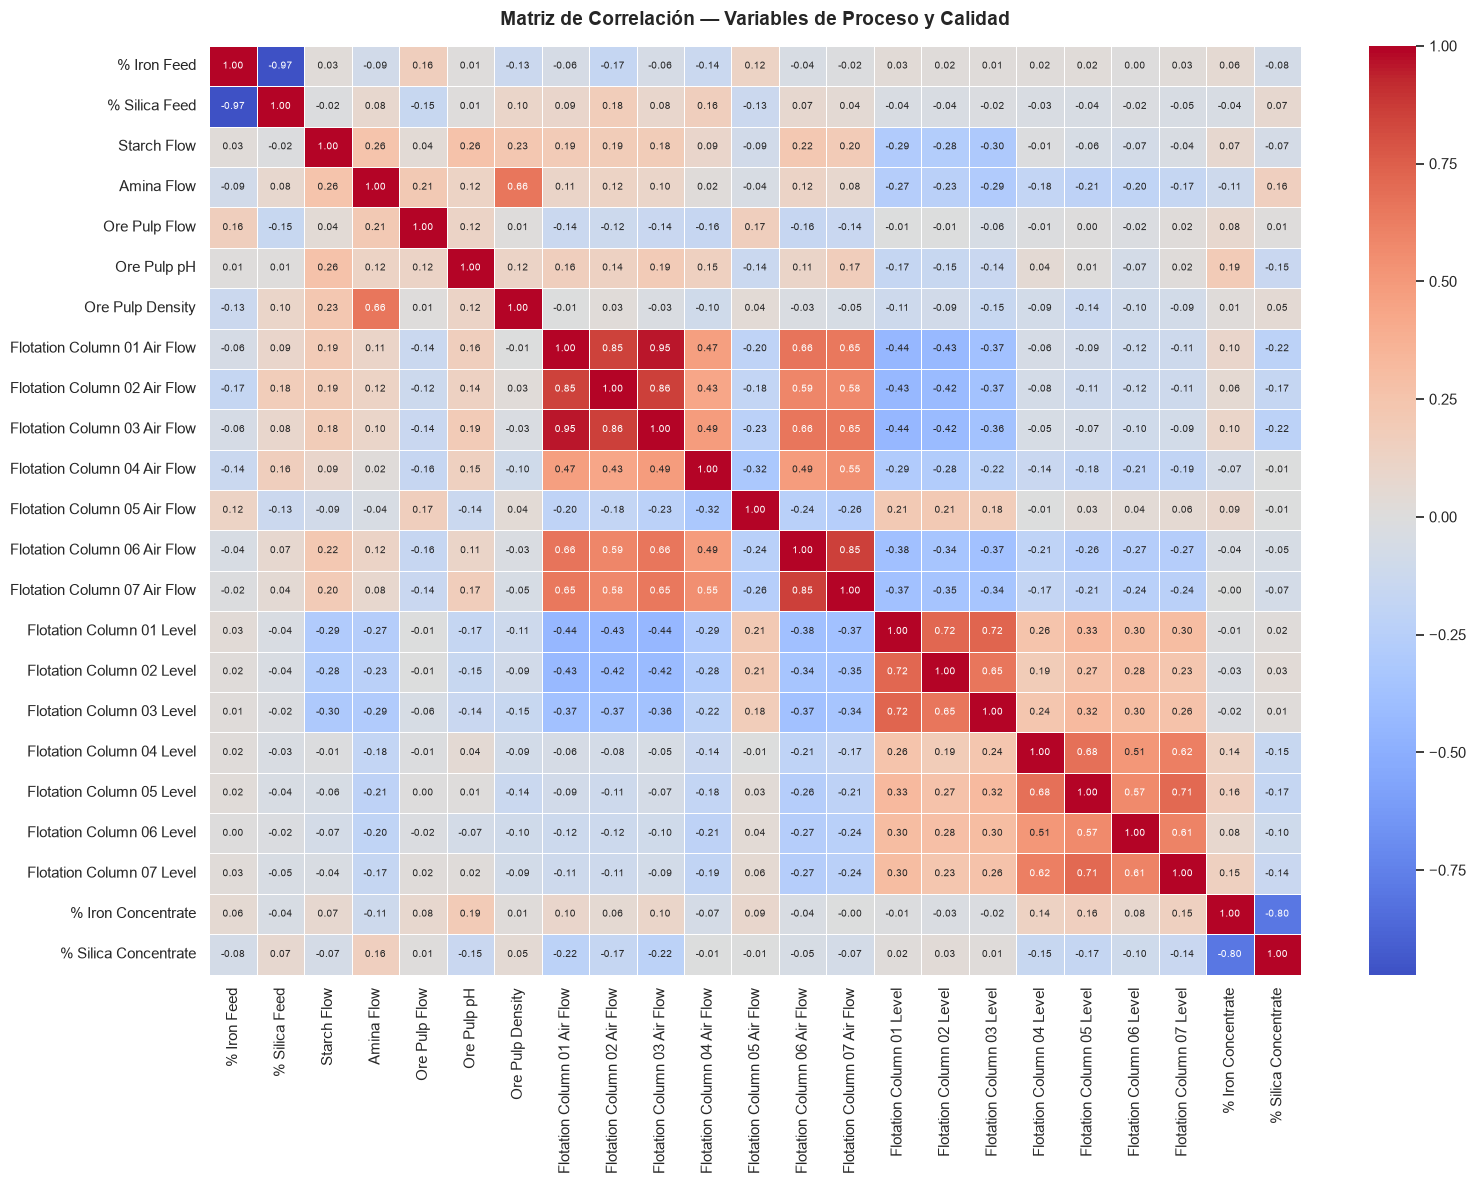

In [64]:
# --- 7.2 Heatmap de correlaciones ---
plot_heatmap_correlaciones(correlaciones)

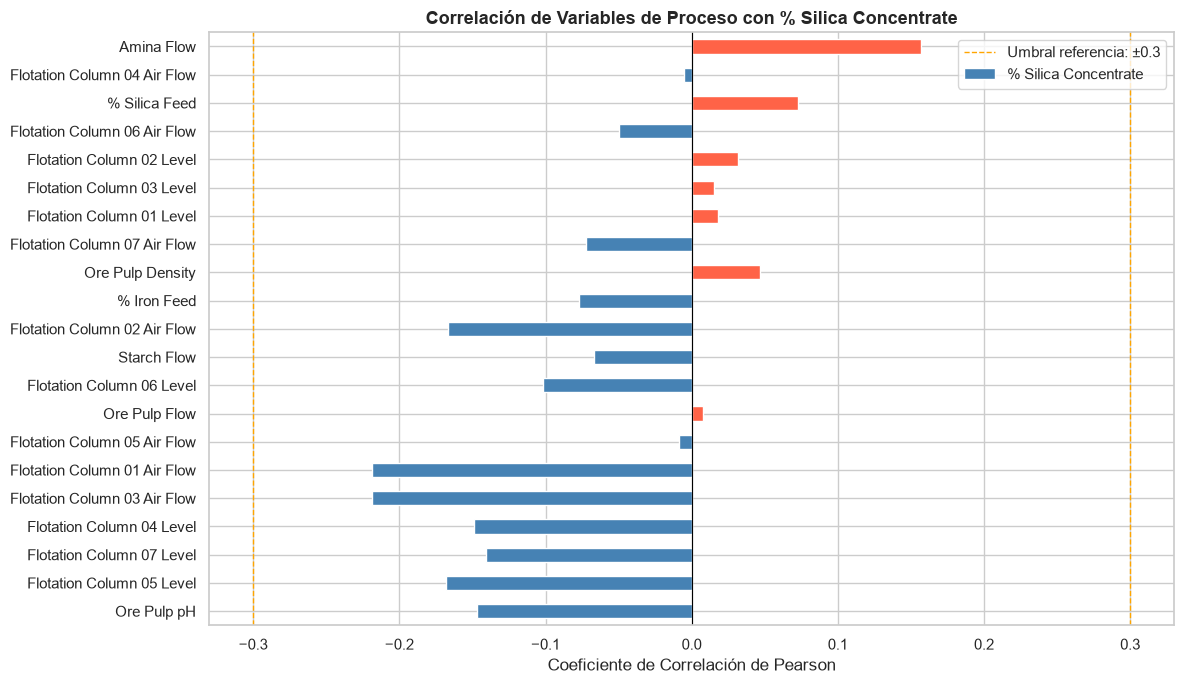

In [65]:
# --- 7.3 Correlaciones con % Silica Concentrate (variable crítica) ---
plot_barras_correlacion_silice(corr_calidad)

### 7.4 Interpretación — Correlaciones

**Variables con mayor correlación positiva con % Silica Concentrate:**
- Amina Flow → **+0.157**
- Ore Pulp pH → **-0.147** (ojo: es negativa, pero entre las más altas en magnitud positiva no hay muchas)
- % Silica Feed → **+0.073**

**Variables con mayor correlación negativa con % Silica Concentrate:**
- Flotation Column 03 Air Flow → **-0.219**
- Flotation Column 01 Air Flow → **-0.219**
- Flotation Column 02 Air Flow → **-0.167**

**Variables con mayor correlación con % Iron Concentrate:**
- Ore Pulp pH → **+0.192**
- Flotation Column 05 Level → **+0.160**
- Flotation Column 07 Level → **+0.146**

**Hallazgo principal:**
La **aireación en columnas de flotación (Columnas 01 y 03)** es la variable operativa más crítica, ya que muestra la correlación negativa más fuerte con la sílice en el concentrado.

**Implicancia operativa:**
El operador debería **monitorear y ajustar en tiempo real los caudales de aire en las columnas de flotación**, ya que un control más fino en esta variable puede reducir la variabilidad de sílice y mejorar la calidad del concentrado.

**Magnitud general de las correlaciones:**
[Por qué ninguna supera 0.3 y qué significa en un proceso bajo control]

**Hallazgo — Amina Flow y causalidad inversa:**
[Feedback loop, control reactivo, por qué sube junto con la sílice]

**Limitación del análisis de Pearson:**
[Qué no puede responder este análisis solo]


## 8. Conclusiones y Hallazgos Finales

### Resumen Ejecutivo

El proceso de flotación analizado demuestra una alta capacidad para mantener la ley de hierro dentro de los estándares comerciales, aunque la sílice actúa como el principal factor de riesgo para la calidad final debido a su alta volatilidad. Se identificaron periodos específicos de inestabilidad operativa en abril y agosto donde la eficiencia de separación falló sistémicamente. El control de la planta parece ser reactivo, especialmente en el uso de reactivos como la amina, y se identificó que la aireación de las columnas es la palanca operativa con mayor impacto directo en la reducción de impurezas.

### Hallazgos Técnicos

1. **Calidad del hierro:**  
   Estable en torno al 65%, con variaciones acotadas (CV ≈ 1.7%). Es el mejor indicador de estabilidad del proceso.

2. **Variabilidad de la sílice:**  
   Alta dispersión (CV ≈ 48%), con picos >4% que comprometen la calidad comercial. Es la variable más crítica y volátil.

3. **Parada de mantenimiento:**  
   Se registró un vacío de datos de 12 días consecutivos (17–28 marzo 2017), interpretado como parada programada de planta para mantenimiento mayor o cambio de campaña.

4. **Días críticos:**  
   Se identificaron 6 fechas (23 abril, 06 mayo, 10 mayo, 04 agosto, 30 agosto, 05 septiembre) con hierro <64% y sílice >4% simultáneamente, representando fallas sistémicas en la separación.

5. **Variable operativa más influyente:**  
   Los caudales de aire en columnas de flotación (Columnas 01 y 03) muestran la correlación negativa más fuerte con la sílice, siendo el factor operativo clave para mejorar la calidad.

---

### Variables Críticas Identificadas
A continuación, se listan las variables que requieren monitoreo prioritario según su impacto en la sílice (impureza principal):
- **Amina Flow (+0.157)**: Actúa como indicador de inestabilidad; niveles altos de amina revelan esfuerzos del sistema por compensar picos de sílice.
- **Ore Pulp pH (-0.147)**: Presenta el mejor balance, ya que un pH más alto se correlaciona con más hierro y menos sílice simultáneamente.
- **Flotation Column 01 & 03 Air Flow (-0.219)** : Variables críticas de control directo para la reducción de impurezas.

### Próximos Pasos Sugeridos
- **Análisis de Retardos (Lags)**: Investigar el tiempo que transcurre desde que se ajusta un reactivo (causa) hasta que impacta en el sensor de calidad final (efecto), para mejorar la precisión de las correlaciones.
- **Modelado Predictivo**: Avanzar hacia un modelo de Machine Learning que permita predecir el % de sílice con 1 o 2 horas de antelación, permitiendo ajustes proactivos en lugar de reactivos.
- **Escalabilidad del Proyecto**: Continuar con la modularización del código en archivos .py (como src/plots.py), siguiendo las recomendaciones de Wilson et al. (2017) para garantizar que el análisis sea reproducible y fácil de mantener a medida que se agreguen más meses de datos